# Упражнение 8.8. Однократная и ожидаемая выборка при разной ветвистости

Саттон, Барто, «Обучение с подкреплением».
Полный разбор — в сборнике решений: [глава 8 (PDF)](https://michaeltoschenko.github.io/RL_Sutton_Barto_Solutions/ch08.pdf).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

%matplotlib inline

Matplotlib is building the font cache; this may take a moment.


## Задача

Случайно сгенерированная MDP: $|S|$ состояний, по 2 действия. Каждое действие ведёт в один из $b$ преемников (выбраны случайно, равновероятно). С вероятностью 0.1 любой переход ведёт в терминальное состояние и завершает эпизод. Ожидаемая награда каждого перехода взята из стандартного нормального распределения. Обновления полные (формула 8.1), дисконт $\gamma=0.9$.

In [2]:
TERM = 0.1          # вероятность перехода в терминальное состояние
N_ACT = 2
MAX_UPD = 20000
EPS = 0.1            # доля случайных шагов в стратегии "с единой стратегией"
GAMMA = 0.9          # дисконт

class Task:
    def __init__(self, n_states, b, seed):
        rng = np.random.default_rng(seed)
        self.n = n_states
        self.b = b
        self.succ = rng.integers(n_states, size=(n_states, N_ACT, b))   # преемники для каждой пары
        self.rew = rng.standard_normal((n_states, N_ACT, b))            # ожидаемые награды

def expected_update(Q, task, s, a):
    # полное обновление (8.1)
    Q[s, a] = (1.0 - TERM) * np.mean(task.rew[s, a] + GAMMA * Q[task.succ[s, a]].max(axis=1))

def greedy_start_value(Q, task, eval_rng, rollouts=1000, max_h=300):
    # истинная ценность стартового состояния при жадной стратегии, оценка Монте-Карло
    n, b = task.n, task.b
    ga = Q.argmax(axis=1)
    gsucc = task.succ[np.arange(n), ga]
    grew = task.rew[np.arange(n), ga]
    states = np.zeros(rollouts, dtype=np.int64)
    active = np.ones(rollouts, dtype=bool)
    ret = np.zeros(rollouts)
    discount = 1.0
    for _ in range(max_h):
        if not active.any():
            break
        cont = active & (eval_rng.random(rollouts) >= TERM)
        i = eval_rng.integers(b, size=rollouts)
        sc, ic = states[cont], i[cont]
        ret[cont] += discount * grew[sc, ic]
        states[cont] = gsucc[sc, ic]
        active = cont
        discount *= GAMMA
    return ret.mean()

## Распределение обновлений

- Равномерное: каждую пару состояние-действие обновляем по одному разу, в перемешанном порядке.
- С единой стратегией: имитируем эпизоды из стартового состояния по ε-жадной стратегии и обновляем встреченные пары; после терминального состояния эпизод начинается заново.

По оси ординат — истинная ценность стартового состояния при жадной стратегии (оценка Монте-Карло). Замеры начинаем с нулевого числа обновлений и сгущаем на раннем участке, где значения растут быстрее всего.

In [3]:
def run(task, dist, checkpoints, seed):
    rng = np.random.default_rng(seed + 13)
    eval_rng = np.random.default_rng(seed + 999983)
    Q = np.zeros((task.n, N_ACT))
    cset = set(checkpoints)
    if dist == 'uniform':                       # перемешанный порядок перебора пар
        order = [(s, a) for s in range(task.n) for a in range(N_ACT)]
        rng.shuffle(order)
    vals = []
    s = 0
    if 0 in cset:                               # замер при нулевом Q
        vals.append(greedy_start_value(Q, task, eval_rng))
    for k in range(MAX_UPD):
        if dist == 'uniform':
            su, au = order[k % len(order)]
            expected_update(Q, task, su, au)
        else:  # с единой стратегией
            a = rng.integers(N_ACT) if rng.random() < EPS else int(Q[s].argmax())
            expected_update(Q, task, s, a)
            s = 0 if rng.random() < TERM else int(task.succ[s, a, rng.integers(task.b)])
        if (k + 1) in cset:
            vals.append(greedy_start_value(Q, task, eval_rng))
    return np.array(vals)

## Запуск

Усредняем по 20 случайно сгенерированным задачам для каждого сочетания $b$ и распределения.

In [4]:
n_states = 10000
n_tasks = 20
checkpoints = list(range(0, 1001, 50)) + list(range(1400, MAX_UPD + 1, 400))

configs = [(1, 'onpolicy'), (1, 'uniform'), (3, 'onpolicy'), (3, 'uniform')]
curves = {}
for b, dist in configs:
    acc = np.zeros(len(checkpoints))
    for seed in tqdm(range(n_tasks), desc='b=%d, %s' % (b, dist)):
        acc += run(Task(n_states, b, seed), dist, checkpoints, seed)
    curves[(b, dist)] = acc / n_tasks

b=3, uniform: 100%|██████████| 20/20 [00:03<00:00,  5.93it/s]


## График

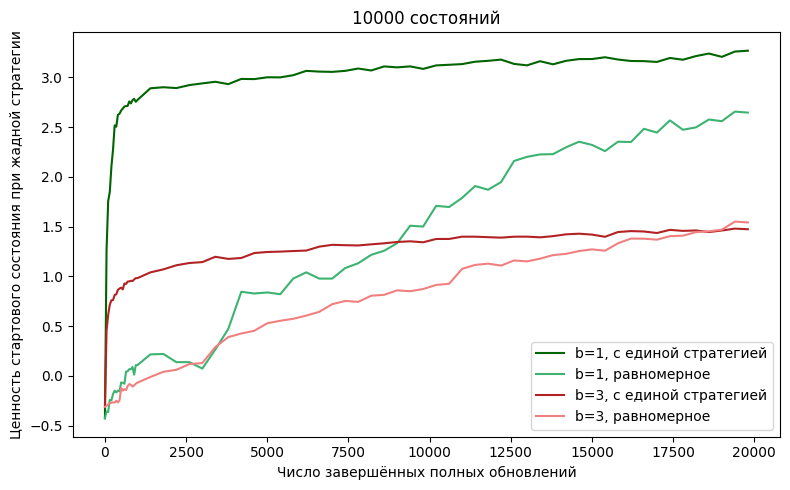

In [5]:
styles = {
    (1, 'onpolicy'): ('darkgreen',      'b=1, с единой стратегией'),
    (1, 'uniform'):  ('mediumseagreen', 'b=1, равномерное'),
    (3, 'onpolicy'): ('firebrick',      'b=3, с единой стратегией'),
    (3, 'uniform'):  ('lightcoral',     'b=3, равномерное'),
}
plt.figure(figsize=(8, 5))
for key in configs:
    color, label = styles[key]
    plt.plot(checkpoints, curves[key], color=color, label=label)
plt.xlabel('Число завершённых полных обновлений')
plt.ylabel('Ценность стартового состояния при жадной стратегии')
plt.title('10000 состояний')
plt.legend()
plt.tight_layout()
plt.show()